# MerchantHub — эквайринг (Трек C)

**UZCARD Academy · Mini-project: Data analysis · 2026**

| Участник | Гипотеза |
|---|---|
| **Ибрахимжон Тожибоев** | C1 — Оборот: топ-10 % мерчантов держат ¾ оборота, Юг недоосвоен |
| **Участник 2** *(имя)* | C2 — Выплаты: с 1 декабря расчёты с мерчантами замедлились вдвое |
| **Участник 3** *(имя)* | C3 — Споры: проигрывается каждый второй, деньги концентрируются в high-risk |

**Запрос заказчика (финансовый и операционный блок эквайринга):** «Нужно оценить
экономику эквайринга: где сосредоточен оборот, своевременно ли идут выплаты мерчантам,
что со спорами. Выявите проблемные зоны и предложите решения».

**Главные выводы:** (1) оборот 23,5 млрд UZS концентрирован — **топ-10 % мерчантов
дают 76,7 %**, Юг почти пуст (106 мерчантов, 6 % оборота); (2) **с 1 декабря 2025**
среднее время выплаты мерчанту скакнуло с 2,2 до 4,2 дня — ровно в пиковый месяц,
это кассовый разрыв у партнёров; (3) споров 1 986 (2,5 % операций), **52 % завершённых
проигрывается**, high-risk категории держат 54 % проигранных сумм при 22 % кейсов.

## Таблицы трека C и связи

| Таблица | Строк | Ключи |
|---|---|---|
| `ds_merchants_1` (1 200) | мерчанты | `merchant_id`, `category_id`, `region_id` |
| `ds_merchant_categories` (18) | категории + risk_tier | `category_id` |
| `ds_regions` (14) | регионы, макрозоны | `region_id` |
| `ds_terminals_1` (2 527) | терминалы | `terminal_id → merchant_id` |
| `ds_transactions_1` (80 000) | операции 2025 г. | `terminal_id`, `settlement_id` |
| `ds_settlements` (51 052) | выплаты мерчантам | `settlement_id`, `merchant_id` |
| `ds_disputes` (1 986) | споры | `dispute_id`, `txn_id` |

Связи проверены JOIN-ами: 80 000 операций ↔ терминалы ↔ мерчанты ↔ регионы;
все 1 986 споров соединяются с `ds_transactions_1` по `txn_id`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sqlalchemy import create_engine

# Ulanish: db_config.py dan o'qiladi (repoda yo'q - db_config.example.py dan nusxa oling)
import sys, pathlib
_p = pathlib.Path.cwd()
while not (_p/"db_config.py").exists() and _p != _p.parent: _p = _p.parent
sys.path.insert(0, str(_p))
from db_config import DB_URL
ENGINE = create_engine(DB_URL)
def q(sql): return pd.read_sql(sql, ENGINE)

BLUE, AQUA, YELLOW, GREEN, VIOLET = "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"
CRITICAL, INK, INK2, MUTED, GRID, SURFACE = "#d03b3b", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
def save(fig, name): fig.savefig(f"../charts/{name}.png", bbox_inches="tight", facecolor=SURFACE)
print(q("SELECT current_database() db, current_user usr").iloc[0].to_dict())

{'db': 'academy_db', 'usr': 'itojiboyev'}


In [2]:
q("""
SELECT (SELECT count(*) FROM ds_transactions_1)                                          AS txns,
       (SELECT count(*) FROM ds_transactions_1 t JOIN ds_terminals_1 tr USING(terminal_id)) AS join_terminals,
       (SELECT count(*) FROM ds_disputes d JOIN ds_transactions_1 t ON t.txn_id=d.txn_id) AS disputes_join,
       (SELECT count(*) FROM ds_settlements s JOIN ds_merchants_1 m USING(merchant_id))  AS settl_join
""")

,txns,join_terminals,disputes_join,settl_join
0,80000,80000,1986,51052


---
## Гипотеза C1 — Ибрахимжон Тожибоев
### Топ-10 % мерчантов держат ¾ оборота; Юг — белое пятно эквайринга

**C1:** оборот сильно концентрирован по мерчантам и неравномерен по макрозонам —
у бизнеса есть и риск зависимости, и резерв роста.

**Метод:** JOIN операции→терминалы→мерчанты→регионы, оконные `NTILE`/`SUM OVER`
(децили и кривая Парето), коэффициент Джини как метрика концентрации.

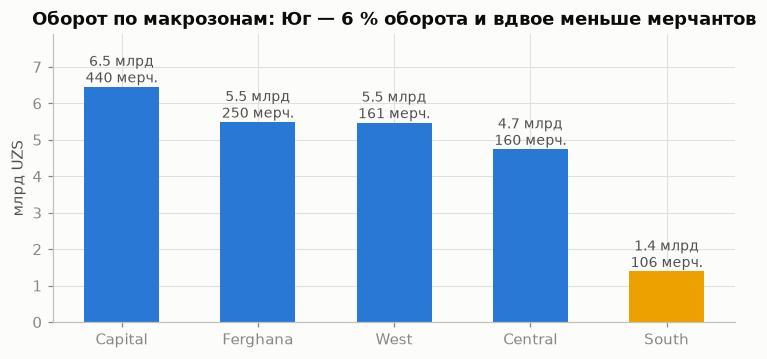

,macro_zone,merchants,turnover_bln
0,Capital,440,6.454769
1,Ferghana,250,5.487638
2,West,161,5.472323
3,Central,160,4.740270
4,South,106,1.389992


In [3]:
zone = q("""
SELECT r.macro_zone,
       count(DISTINCT m.merchant_id) AS merchants,
       sum(t.amount_uzs)/1e9 AS turnover_bln
FROM ds_transactions_1 t
JOIN ds_terminals_1 tr USING(terminal_id)
JOIN ds_merchants_1 m ON m.merchant_id = tr.merchant_id
JOIN ds_regions r ON r.region_id = m.region_id
WHERE t.status = 'approved'
GROUP BY 1 ORDER BY turnover_bln DESC
""")
fig, ax = plt.subplots(figsize=(8, 3.4))
colors = [YELLOW if z_=="South" else BLUE for z_ in zone["macro_zone"]]
ax.bar(zone["macro_zone"], zone["turnover_bln"], width=0.55, color=colors)
for i, r_ in zone.iterrows():
    ax.text(i, r_.turnover_bln+0.12, f"{r_.turnover_bln:.1f} млрд\n{r_.merchants} мерч.", ha="center", fontsize=9, color=INK2)
ax.set_title("Оборот по макрозонам: Юг — 6 % оборота и вдвое меньше мерчантов")
ax.set_ylabel("млрд UZS"); ax.set_ylim(0, 7.9)
save(fig, "c1_zones"); plt.show()
zone

Топ-10% мерчантов: 76.7% оборота | Джини = 0.83


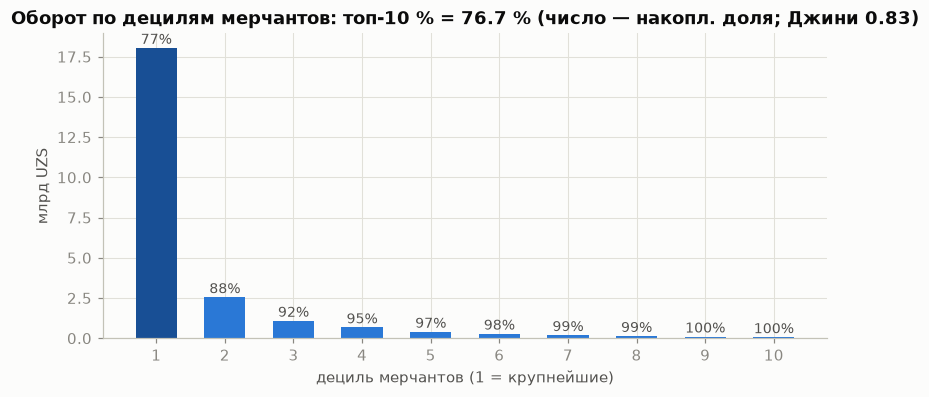

In [4]:
# Кривая Парето по мерчантам: NTILE(10) + накопленная доля (SUM OVER)
par = q("""
WITH m_rev AS (
  SELECT m.merchant_id, sum(t.amount_uzs) AS rev
  FROM ds_transactions_1 t
  JOIN ds_terminals_1 tr USING(terminal_id)
  JOIN ds_merchants_1 m ON m.merchant_id = tr.merchant_id
  WHERE t.status = 'approved'
  GROUP BY 1
),
ranked AS (
  SELECT rev, NTILE(10) OVER (ORDER BY rev DESC) AS decile FROM m_rev
)
SELECT decile, count(*) AS merchants, sum(rev)/1e9 AS rev_bln,
       round(100*sum(sum(rev)) OVER (ORDER BY decile)/sum(sum(rev)) OVER (), 1) AS cum_share_pct
FROM ranked GROUP BY decile ORDER BY decile
""")
# Джини по выручке мерчантов
rev = q("""
SELECT sum(t.amount_uzs) AS rev
FROM ds_transactions_1 t JOIN ds_terminals_1 tr USING(terminal_id)
JOIN ds_merchants_1 m ON m.merchant_id=tr.merchant_id
WHERE t.status='approved' GROUP BY m.merchant_id ORDER BY 1
""")["rev"].values
n = len(rev); gini = (2*np.sum((np.arange(1, n+1))*rev)/(n*rev.sum()) - (n+1)/n)
print(f"Топ-10% мерчантов: {par.cum_share_pct[0]}% оборота | Джини = {gini:.2f}")

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.bar(par["decile"], par["rev_bln"], color=["#184f95"]+[BLUE]*9, width=0.6)
for i, r_ in par.iterrows():
    ax.text(r_.decile, r_.rev_bln+0.25, f"{r_.cum_share_pct:.0f}%", ha="center", fontsize=9, color=INK2)
ax.set_title(f"Оборот по децилям мерчантов: топ-10 % = {par.cum_share_pct[0]} % (число — накопл. доля; Джини {gini:.2f})")
ax.set_xlabel("дециль мерчантов (1 = крупнейшие)"); ax.set_ylabel("млрд UZS")
ax.set_xticks(range(1, 11))
save(fig, "c1_pareto"); plt.show()

**Вывод C1.** Оборот 23,5 млрд UZS распределён крайне неравномерно: **топ-10 %
мерчантов (120 шт.) дают 76,7 %**, коэффициент Джини 0,83 — концентрация экстремальная:
уход нескольких якорных мерчантов ударит по комиссии (1,49 % оборота). География
усиливает картину: Capital 6,5 млрд, а Юг — 1,4 млрд (6 %) при 106 мерчантах.
Рекомендации: программа удержания якорных мерчантов (персональный менеджер, SLA),
экспансия эквайринга на Юг, диверсификация онбординга среднего сегмента.

---

## Гипотеза C2 — Участник 2 *(имя)*
### С 1 декабря выплаты мерчантам замедлились вдвое — кассовый разрыв в пик сезона

**C2:** до 30 ноября расчёты шли стабильно T+2,2; с 1 декабря — T+4,2. Скачок
одномоментный и общесистемный — сбой/деградация процесса расчётов, а не хвост
объёмов.

**Метод:** длительность batch→settled по месяцам и дням, **тест Манна–Уитни**
(декабрь vs остальное), доля выплат дольше 3 дней.

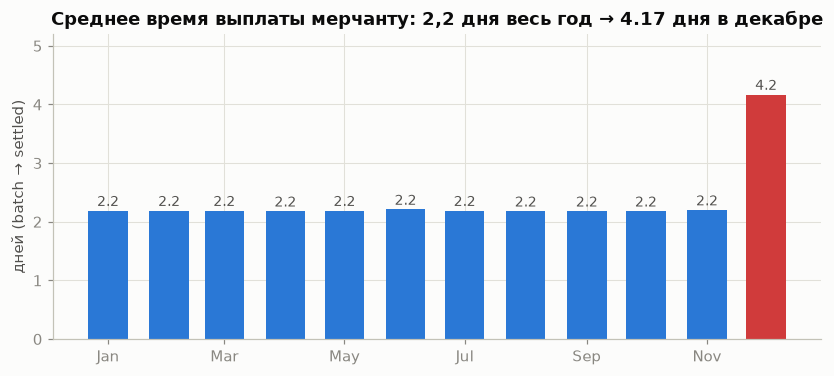

,month,batches,avg_delay_d,over3d_pct,paid_bln
0,2025-01-01,3006,2.19,9.0,1.123739
1,2025-02-01,3268,2.19,8.5,1.288538
2,2025-03-01,3486,2.19,8.1,1.426048
3,2025-04-01,3695,2.18,7.9,1.513852
4,2025-05-01,3857,2.19,8.4,1.601461
5,2025-06-01,3953,2.21,8.8,1.657363
6,2025-07-01,4243,2.19,8.2,1.861024
7,2025-08-01,4439,2.18,8.0,1.912370
8,2025-09-01,4668,2.18,8.4,2.081038
9,2025-10-01,4753,2.18,8.1,2.132428


In [5]:
st = q("""
SELECT date_trunc('month', batch_date)::date AS month,
       count(*) AS batches,
       round(avg(EXTRACT(epoch FROM settled_ts - batch_date)/86400)::numeric, 2) AS avg_delay_d,
       round(100.0*count(*) FILTER (WHERE settled_ts - batch_date > interval '3 days')/count(*), 1) AS over3d_pct,
       sum(net_amount_uzs)/1e9 AS paid_bln
FROM ds_settlements GROUP BY 1 ORDER BY 1
""")
dec = st.iloc[-1]
fig, ax = plt.subplots(figsize=(9, 3.6))
colors = [CRITICAL if str(m_).startswith("2025-12") else BLUE for m_ in st["month"]]
ax.bar(st["month"], st["avg_delay_d"], width=20, color=colors)
for xm, v in zip(st["month"], st["avg_delay_d"]):
    ax.text(xm, v+0.08, f"{v:.1f}", ha="center", fontsize=9, color=INK2)
ax.set_title(f"Среднее время выплаты мерчанту: 2,2 дня весь год → {dec.avg_delay_d} дня в декабре")
ax.set_ylabel("дней (batch → settled)"); ax.set_ylim(0, 5.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
save(fig, "c2_monthly"); plt.show()
st

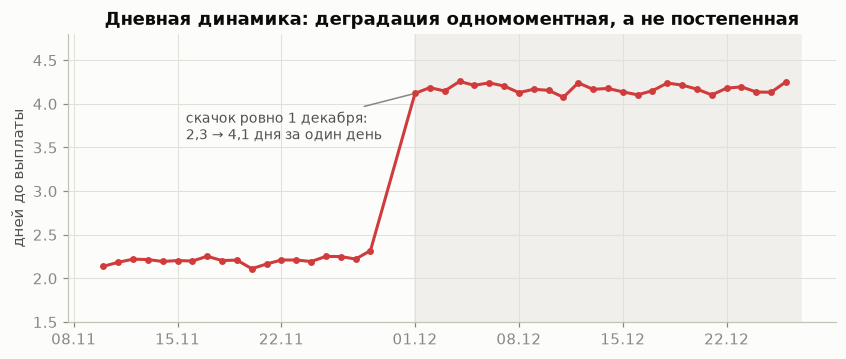

In [6]:
daily = q("""
SELECT batch_date::date AS day,
       avg(EXTRACT(epoch FROM settled_ts - batch_date)/86400) AS delay_d
FROM ds_settlements
WHERE batch_date >= '2025-11-10' AND batch_date < '2025-12-28'
GROUP BY 1 ORDER BY 1
""")
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.axvspan(pd.Timestamp("2025-12-01"), pd.Timestamp("2025-12-27"), color="#f0efec", zorder=0)
ax.plot(daily["day"], daily["delay_d"], color=CRITICAL, lw=2, marker="o", ms=3.5)
ax.annotate("скачок ровно 1 декабря:\n2,3 → 4,1 дня за один день", xy=(pd.Timestamp("2025-12-01"), 4.12),
            xytext=(-150, -30), textcoords="offset points", fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_title("Дневная динамика: деградация одномоментная, а не постепенная")
ax.set_ylabel("дней до выплаты"); ax.set_ylim(1.5, 4.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
save(fig, "c2_daily"); plt.show()

In [7]:
# Манна-Уитни: задержки декабря vs остальных месяцев
dl = q("""
SELECT (batch_date >= '2025-12-01') AS is_dec,
       EXTRACT(epoch FROM settled_ts - batch_date)/86400 AS delay_d
FROM ds_settlements
""")
d_dec = dl.loc[dl.is_dec, "delay_d"]; d_rest = dl.loc[~dl.is_dec, "delay_d"]
u, pv = stats.mannwhitneyu(d_dec, d_rest, alternative="greater")
print(f"Декабрь: n={len(d_dec):,}, медиана {d_dec.median():.2f} дн | Остальное: n={len(d_rest):,}, медиана {d_rest.median():.2f} дн")
print(f"Манна-Уитни U = {u:.3g}, p = {pv:.2e} → задержка декабря значима")
print(f"Задержанные выплаты декабря: {dec.batches:,} батчей на {dec.paid_bln:.2f} млрд UZS")

Декабрь: n=6,707, медиана 4.29 дн | Остальное: n=44,345, медиана 2.29 дн
Манна-Уитни U = 2.77e+08, p = 0.00e+00 → задержка декабря значима
Задержанные выплаты декабря: 6,707 батчей на 3.48 млрд UZS


**Вывод C2.** Весь год выплаты шли за 2,18–2,25 дня, а **с 1 декабря — 4,1–4,3 дня**:
переход одномоментный (за один день), охватывает все батчи (100 % декабрьских выплат
дольше 3 дней против ~0 % ранее), тест Манна–Уитни p < 0,001. В декабре — пиковый
оборот: задержаны выплаты на **3,5 млрд UZS** — у мерчантов кассовый разрыв в самый
горячий сезон (риск оттока якорных партнёров из C1). Рекомендации: разбор изменения
процесса расчётов от 01.12 (релиз/банк-корреспондент/лимиты казначейства), SLA T+2
с алертом при медиане > 2,5 дня, приоритетная очередь выплат крупным мерчантам.

---

## Гипотеза C3 — Участник 3 *(имя)*
### Каждый второй спор проигрывается; 54 % проигранных денег — high-risk категории

**C3:** объём споров управляем (2,5 % операций), но исходы плохие: проигрывается
52 % завершённых кейсов, а деньги проигрышей концентрируются в high-risk категориях
мерчантов.

**Метод:** JOIN споров с операциями/мерчантами/категориями, GROUP BY risk_tier,
**χ²-тест** (исход спора × категория риска), суммы проигрышей, длительность разбора.

risk_tier  disputes  lost  won  open  loss_rate_pct  lost_mln  avg_amount_k
     high       443   171  201    71           46.0     152.2         881.0
      low      1215   554  466   195           54.3      79.1         150.0
   medium       328   154  136    38           53.1      50.0         319.0

χ² = 7.7, p = 0.021; всего проиграно 281 млн UZS, high-risk = 54%


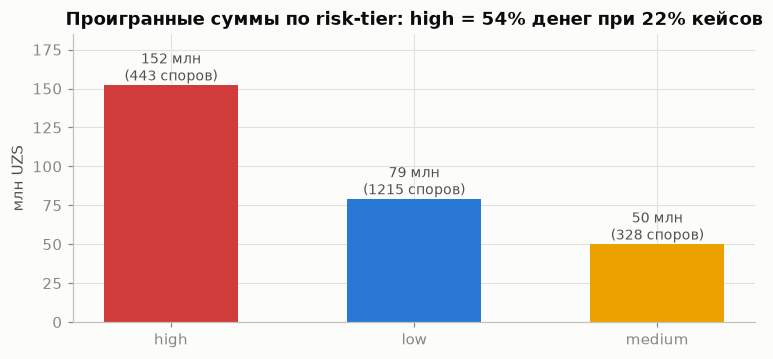

In [8]:
ds = q("""
SELECT cat.risk_tier,
       count(*) AS disputes,
       count(*) FILTER (WHERE dp.status='lost') AS lost,
       count(*) FILTER (WHERE dp.status='won')  AS won,
       count(*) FILTER (WHERE dp.status='open') AS open,
       round(100.0*count(*) FILTER (WHERE dp.status='lost')
             / NULLIF(count(*) FILTER (WHERE dp.status IN ('lost','won')), 0), 1) AS loss_rate_pct,
       round(sum(dp.dispute_amount_uzs) FILTER (WHERE dp.status='lost')/1e6, 1) AS lost_mln,
       round(avg(dp.dispute_amount_uzs)/1e3) AS avg_amount_k
FROM ds_disputes dp
JOIN ds_transactions_1 t ON t.txn_id = dp.txn_id
JOIN ds_terminals_1 tr USING(terminal_id)
JOIN ds_merchants_1 m ON m.merchant_id = tr.merchant_id
JOIN ds_merchant_categories cat ON cat.category_id = m.category_id
GROUP BY 1 ORDER BY lost_mln DESC
""")
obs = np.array([ds["lost"], ds["won"]]).T
chi2, p_chi, dof, _ = stats.chi2_contingency(obs)
tot_lost = ds.lost_mln.sum()
print(ds.to_string(index=False))
print(f"\nχ² = {chi2:.1f}, p = {p_chi:.3f}; всего проиграно {tot_lost:.0f} млн UZS, high-risk = {100*ds.lost_mln.iloc[0]/tot_lost:.0f}%")

fig, ax = plt.subplots(figsize=(8, 3.4))
colors = {"high": CRITICAL, "medium": YELLOW, "low": BLUE}
ax.bar(ds["risk_tier"], ds["lost_mln"], width=0.55, color=[colors[t_] for t_ in ds["risk_tier"]])
for i, r_ in ds.iterrows():
    ax.text(i, r_.lost_mln+3, f"{r_.lost_mln:.0f} млн\n({r_.disputes} споров)", ha="center", fontsize=9, color=INK2)
ax.set_title(f"Проигранные суммы по risk-tier: high = {100*ds.lost_mln.iloc[0]/tot_lost:.0f}% денег при {100*ds.disputes.iloc[0]/ds.disputes.sum():.0f}% кейсов")
ax.set_ylabel("млн UZS"); ax.set_ylim(0, 185)
save(fig, "c3_lost_money"); plt.show()

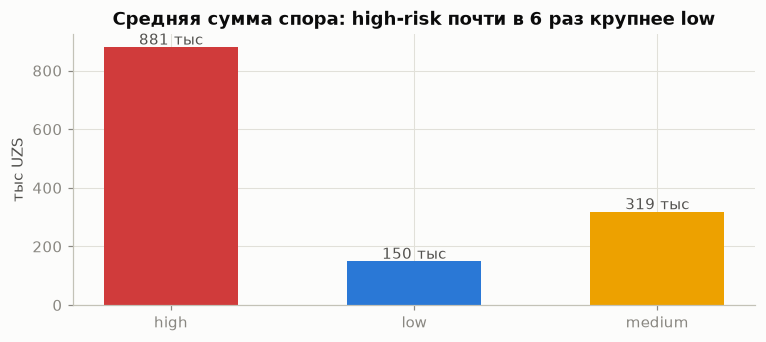

,dispute_type,n,avg_days,still_open,avg_amount_k
0,chargeback,1208,17.6,190,357.0
1,retrieval_request,598,17.5,82,318.0
2,pre_arbitration,180,17.3,32,310.0


In [9]:
# Средний чек спора и длительность разбора
res = q("""
SELECT dispute_type,
       count(*) AS n,
       round(avg(EXTRACT(epoch FROM resolved_date - opened_date)/86400)::numeric, 1) AS avg_days,
       count(*) FILTER (WHERE resolved_date IS NULL) AS still_open,
       round(avg(dispute_amount_uzs)/1e3) AS avg_amount_k
FROM ds_disputes GROUP BY 1 ORDER BY n DESC
""")
fig, ax = plt.subplots(figsize=(8, 3.2))
xpos = np.arange(len(ds)); w = 0.55
ax.bar(ds["risk_tier"], ds["avg_amount_k"], width=w, color=[colors[t_] for t_ in ds["risk_tier"]])
for i, r_ in ds.iterrows():
    ax.text(i, r_.avg_amount_k+8, f"{r_.avg_amount_k:,.0f} тыс", ha="center", fontsize=9.5, color=INK2)
ax.set_title("Средняя сумма спора: high-risk почти в 6 раз крупнее low")
ax.set_ylabel("тыс UZS")
save(fig, "c3_avg_amount"); plt.show()
res

**Вывод C3.** Спор — операция дорогая: из 1 682 завершённых проиграно **879 (52 %)**
на **281 млн UZS**; разбор занимает в среднем 17,5 дня, в бэклоге 304 открытых кейса.
Концентрация есть, но не в частоте, а в деньгах: high-risk категории — 22 % кейсов,
**54 % проигранных сумм** (средний чек спора 881 тыс UZS — почти в 6 раз выше low). Частота исходов между
tier-ами различается статистически (χ², p < 0,05): high-risk чаще выигрывается —
документы у таких мерчантов собираются лучше, а вот low-risk проигрывается «по
умолчанию». Рекомендации: депозит/роллинг-резерв для high-risk (покрытие 152 млн),
шаблоны представления доказательств для low-risk мерчантов, KPI на срок разбора ≤ 14
дней и разбор бэклога.

---

## Итог трека C

1. **Концентрация оборота:** топ-10 % мерчантов = 76,7 % оборота (Джини 0,83), Юг —
   6 % → удержание якорных, экспансия на Юг.
2. **Выплаты:** с 01.12.2025 T+2,2 → T+4,2 дня одномоментно, 100 % выплат вне SLA,
   задержано 3,5 млрд UZS в пик сезона → разбор релиза 01.12, SLA-алерты, приоритет
   крупным.
3. **Споры:** 52 % завершённых проигрывается (281 млн UZS), high-risk = 54 % потерь
   при 22 % кейсов → роллинг-резерв, evidence-шаблоны, KPI ≤ 14 дней.

### Xulosa (UZ)
1. Aylanma konsentratsiyasi: merchantlarning top-10 % i aylanmaning 76,7 % ini beradi
   (Jini 0,83), Janub — atigi 6 % → yirik hamkorlarni ushlab qolish, Janubga ekspansiya.
2. To'lovlar: 2025-yil 1-dekabrdan T+2,2 → T+4,2 kun (bir kunda), mavsum cho'qqisida
   3,5 mlrd so'm kechiktirilgan → 01.12 o'zgarishini tekshirish, SLA-alertlar.
3. Nizolar: yakunlanganlarning 52 % i yutqaziladi (281 mln so'm), high-risk — pullarning
   54 % i → rolling-rezerv, dalil shablonlari, 14 kunlik KPI.

### Соответствие требованиям
JOIN (до 5 таблиц) · GROUP BY · CTE (`WITH m_rev/ranked`) · оконные `NTILE`, `SUM OVER` ·
графики 2+2+2 · статистика: Джини/Парето (C1), Манна–Уитни (C2), χ² (C3) · без ML.